In [1]:
import pandas as pd
import re

In [2]:
df = pd.read_csv('data/cleaned/general_stores_sorted_from_excelsheets.csv')

In [3]:
# make date columns datetime format so I can sort them

date_cols = [
    "DateOfIncorporation",
    "DissolvedDate",
    "TerminationDate",
    "ExpirationDate",
]

df[date_cols] = df[date_cols].apply(pd.to_datetime)

### Q1: When were the most stores dissolved or terminated?

In [4]:
# make a sub-df with just those stores that have dissolved or terminated statuses
dissolved_or_terminated_rows = df[
    (df["BusinessStatus"] == "Dissolved")
    | (df["BusinessStatus"] == "Terminated")
]

Now combine all of the dates into a series, drop null values, and group them

In [5]:
# now make series of all disolved or terminated dates
# by stacking the two datetime series vertically into one sequence
dissolved_or_terminated_dates = pd.concat([
    dissolved_or_terminated_rows["DissolvedDate"],
    dissolved_or_terminated_rows["TerminationDate"],
])

# clean the combined series by dropping nulls
clean_dissolved_or_terminated_dates = dissolved_or_terminated_dates.dropna()

# create decade groups
dissolved_or_terminated_decade_start = (clean_dissolved_or_terminated_dates.dt.year // 10) * 10
dissolved_or_terminated_halfdecade_start = (clean_dissolved_or_terminated_dates.dt.year // 5) * 5

# create decade groups
# // divides two numbers and rounds the result down to the nearest whole integer, so for ex. 1972 --> 1970. That means the "1970" bucket will represent 1970-1980
dissolved_or_terminated_decade_range = dissolved_or_terminated_decade_start.astype(str) + '-' + ((dissolved_or_terminated_decade_start + 9).astype(str))
dissolved_or_terminated_halfdecade_range = dissolved_or_terminated_halfdecade_start.astype(str) + '-' + ((dissolved_or_terminated_halfdecade_start + 4).astype(str))




In [6]:
dissolved_or_terminated_decade_range.value_counts()
dissolved_or_terminated_halfdecade_range.value_counts()

2010-2014    15
2005-2009    14
2015-2019    11
1985-1989    10
1995-1999    10
2000-2004    10
2020-2024     8
1990-1994     7
2025-2029     3
1980-1984     1
Name: count, dtype: int64

Now export just that information about frequency of year terminated/dissolved

In [7]:
# Count by year
year_counts = (
    dissolved_or_terminated_dates.dt.year
    .value_counts()
    .sort_index()
    .rename_axis("years")
    .reset_index(name="count")
)

# Export to CSV
year_counts.to_csv("docs/dissolved_terminated_by_year.csv", index=False)


Now exporting same info but in decade and half decade form for use as needed in story

In [8]:
decade_counts = (
    dissolved_or_terminated_decade_range
    .value_counts()
    .sort_index()
    .rename_axis("years")
    .reset_index(name="count")
)

decade_counts.to_csv("docs/dissolved_terminated_by_decade.csv", index=False)

In [9]:
halfdecade_counts = (
    dissolved_or_terminated_halfdecade_range
    .value_counts()
    .sort_index()
    .rename_axis("years")
    .reset_index(name="count")
)

halfdecade_counts.to_csv("docs/dissolved_terminated_by_halfdecade.csv", index=False)

<Axes: xlabel='years'>

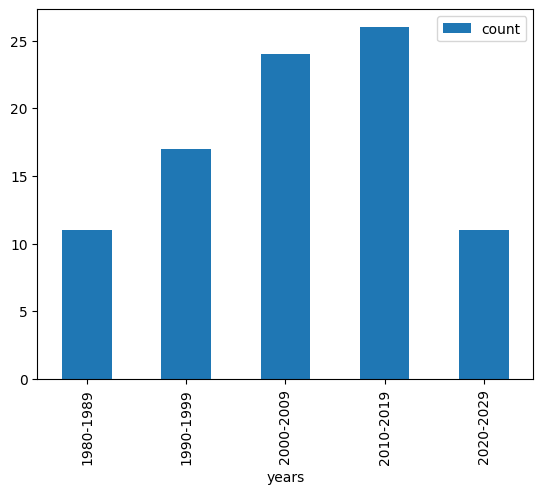

In [11]:
decade_counts.plot(x='years', y='count', kind="bar")

### When were the most stores incorporated?

<Axes: xlabel='DateOfIncorporation'>

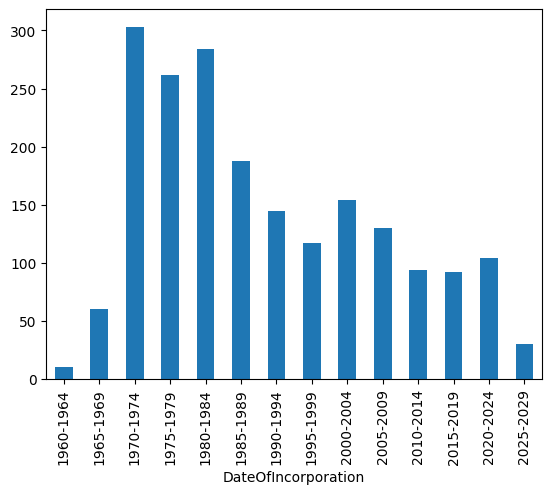

In [12]:
cleaned_incorporation_dates = df["DateOfIncorporation"].dropna()

# create decade groups
# // divides two numbers and rounds the result down to the nearest whole integer, so for ex. 1972 --> 1970. That means the "1970" bucket will represent 1970-1980
incorporation_decade_start = (cleaned_incorporation_dates.dt.year // 10) * 10
incorporation_decade_range = incorporation_decade_start.astype(str) + '-' + ((incorporation_decade_start + 9).astype(str))

incorporation_halfdecade = (cleaned_incorporation_dates.dt.year // 5) * 5
incorporation_halfdecade_range = incorporation_halfdecade.astype(str) + '-' + ((incorporation_halfdecade + 4).astype(str))

# graph decades and half decades

incorporation_decade_range.value_counts().sort_index().plot(kind="bar")
incorporation_halfdecade_range.value_counts().sort_index().plot(kind="bar")

Save incorporation info

In [13]:

decade_counts = (
    incorporation_decade_range
    .value_counts()
    .sort_index()
    .rename_axis("years")
    .reset_index(name="count")
)

halfdecade_counts.to_csv('docs/incorporation_by_decade.csv', index=False)

halfdecade_counts = (
    incorporation_halfdecade_range
    .value_counts()
    .sort_index()
    .rename_axis("years")
    .reset_index(name="count")
)

decade_counts.to_csv('docs/incorporation_by_decade.csv', index=False)
halfdecade_counts.to_csv('docs/incorporation_by_halfdecade.csv', index=False)

How many are currently active?

In [14]:
df.shape

(1239, 31)

In [15]:
df["BusinessStatus"].value_counts()

BusinessStatus
Inactive - Expired                            824
Inactive - Administratively Terminated        105
Active - Registered                            82
Active - In Good Standing                      70
Dissolved                                      59
Inactive - Cessated                            47
Terminated                                     26
Active - NOT In Good Standing                  23
Inactive - Dissolved                            1
Inactive - Administratively Revoked             1
Active registered - Reregistration Pending      1
Name: count, dtype: int64

### Poking around a bit more in the data

How many cities were at one point represented?

In [16]:
## CAUTION -- THIS IS AN ESTIAMET BECAUSE THESE ARE OFFICE ADDRESSES AND SOME ARE OUTSIDE VT

# first title case them
df['PrincipalOfficeCity'] = df['PrincipalOfficeCity'].str.title()

# for reference -- non-VT

df_notVT = df[df['PrincipalOfficeState'] != 'VT']

df_notVT


#then count them 

df['PrincipalOfficeCity'].value_counts()

PrincipalOfficeCity
Rutland        17
Shelburne      16
Benson         15
Castleton      15
Stowe          15
               ..
Waitfield       1
Waterbridge     1
Washington      1
Post Mills      1
Bow             1
Name: count, Length: 394, dtype: int64

In [17]:
df[df['BusinessName'] == 'PUTNEY GENERAL STORE']

### THIS IS IMPT: PUTNEY IS AN EX OF A STORE THAT IS INACTIVE - EXPIRED AND INACTIVE - CESSATED
# BUT NOT TERMINATED OR DISSOLVED. PUTNEY'S STORE IS STILL RUNNING

df[df['BusinessName'] == 'CALAIS GENERAL STORE']


,RecordNumber,FileNo,BusinessType,BusinessName,NaicsCodes,PrincipalOfficeAddress1,PrincipalOfficeAddress2,PrincipalOfficeCity,PrincipalOfficeState,PrincipalOfficeZipCode,...,AgentZipCode,DateOfIncorporation,BusinessStatus,LastAnnualReportDate,TerminationDate,FiscalYearMonth,TermDate,DissolvedDate,SubType,ExpirationDate
867,239381,T0145547,Assumed Name,CALAIS GENERAL STORE,NaN,PO BOX 120,NaN,Calais,VT,05650,...,NaN,2005-12-13,Inactive - Expired,NaN,NaT,NaN,NaN,NaT,NaN,2011-02-11


### How many different general stores were active over time?

Make a new dataframe with just the info I want

First, I need to normalize some of the terms in the dataframe so that they are correctly recognized as the same store

In [18]:
# Define which words should be treated as equivalent.
# Left side: variants you might see in the data. Right side: the standard form to use instead.

town_word_replacements = {
    'EAST ': '',
    'E ': '',
    'E.': '',
    'WEST ': '',
    'W ': '',
    'W.': '',
    'NORTH ': '',
    'N ': '',
    'N.': '',
    'SOUTH ': '',
    'S ': '',
    'S.': '',
    'ST ': 'Saint ',
    'ST. ': 'Saint ',
    'CENTER ': '',
    'CTR': '',
    'SO ': '',
    '.': '',

    # I need to sort nearby towns together to be able to group stores that are actually the same store
    # but listed in different towns next to eachother in different years

    'Marshfield': 'Marshfield/Plainfield',
    'Plainfield': 'Marshfield/Plainfield',
    'FILD': ''
    
}

business_word_replacements = {
    'THE': '',
    'LLC': '',
    'INC': '',
    'CORP': '',
    'LTD': '',
    'COUNTRY STORE': 'STORE',
    'GENERAL STORE': 'STORE',
    'HISTORICA': 'HISTORIC', # appears to be a typo in HISTORICA CRAFTSBURY GENERAL STORE
    "'S": "",
    ",": "",
    ".": "",
    "-": ""
}

# normalize business name

df["business_name_normalized"] = df["BusinessName"].str.upper()

for old, new in business_word_replacements.items():
    df["business_name_normalized"] = df["business_name_normalized"].str.replace(
        old, new, regex=False
    )

df["business_name_normalized"] = (
    df["business_name_normalized"]
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)

# now for town name

df["town_name_normalized"] = df["PrincipalOfficeCity"].str.upper()

for old, new in town_word_replacements.items():
    df["town_name_normalized"] = df["town_name_normalized"].str.replace(
        old, new, regex=False
    )

df["town_name_normalized"] = (
    df["town_name_normalized"]
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
)


In [19]:
df.head(50)

,RecordNumber,FileNo,BusinessType,BusinessName,NaicsCodes,PrincipalOfficeAddress1,PrincipalOfficeAddress2,PrincipalOfficeCity,PrincipalOfficeState,PrincipalOfficeZipCode,...,BusinessStatus,LastAnnualReportDate,TerminationDate,FiscalYearMonth,TermDate,DissolvedDate,SubType,ExpirationDate,business_name_normalized,town_name_normalized
0,55376,V10041,Domestic Business Corporation,"OLD BENNINGTON COUNTRY STORE, INC.",NaN,39 WEST ROAD,NaN,Bennington,VT,05201,...,Dissolved,1985-12-31,NaT,12.0,NaN,1987-03-20,NaN,NaT,OLD BENNINGTON STORE,BENNINGTON
1,55857,V10258,Domestic Business Corporation,"THE VERMONT COUNTRY STORE, INC.",454110-Electronic Shopping and Mail-Order Houses,5650 Main Street,NaN,Manchester Center,VT,05255,...,Active - In Good Standing,2026-04-30,NaT,4.0,0001-01-01,NaT,NaN,NaT,VERMONT STORE,MANCHESTER CENTER
2,57273,V10910,Domestic Business Corporation,"COUNTRY STORE RESTAURANT, INC.",NaN,NaN,NaN,Manchester,VT,05254,...,Inactive - Administratively Terminated,1987-07-31,NaT,7.0,NaN,NaT,NaN,NaT,STORE RESTAURANT,MANCHESTER
3,58742,V11578,Domestic Business Corporation,"GRAFTON VILLAGE STORE, INC.",NaN,5 BROWN STREET,NaN,Bellows Falls,VT,05101,...,Dissolved,2009-12-31,NaT,12.0,NaN,2010-03-10,NaN,NaT,GRAFTON VILLAGE STORE,BELLOWFALLS
4,59684,V12009,Domestic Business Corporation,"CHARLESTOWN MILL STORE OF BENNINGTON, INC.",NaN,PO BOX F,NaN,Charlestown,NH,03603,...,Inactive - Administratively Terminated,1982-06-30,NaT,6.0,NaN,NaT,NaN,NaT,CHARLESTOWN MILL STORE OF BENNINGTON,CHARLESTOWN
5,62004,V13840,Domestic Business Corporation,"BERARDINELLI'S GENERAL STORE, INC.",NaN,MAIN ST RT 104,NaN,Fairfax,VT,05454,...,Inactive - Administratively Terminated,1993-12-31,NaT,12.0,NaN,NaT,NaN,NaT,BERARDINELLI STORE,FAIRFAX
6,63049,V15260,Domestic Business Corporation,"HISTORIC CRAFTSBURY GENERAL STORE, INC.",NaN,MAIN ST.,NaN,Craftsbury,VT,05826,...,Dissolved,1995-09-30,NaT,9.0,NaN,1995-11-08,NaN,NaT,HISTORIC CRAFTSBURY STORE,CRAFTSBURY
7,63967,V16003,Domestic Business Corporation,"WAITS RIVER GENERAL STORE, INC.",NaN,NaN,NaN,Waits River,VT,05086,...,Dissolved,1983-12-31,NaT,12.0,NaN,1985-05-09,NaN,NaT,WAITS RIVER STORE,WAITRIVER
8,64076,V16092,Domestic Business Corporation,"WARDSBORO COUNTRY STORE, INC.",NaN,NaN,NaN,Wardsboro,VT,05355,...,Dissolved,1991-12-31,NaT,12.0,NaN,1992-04-14,NaN,NaT,WARDSBORO STORE,WARDSBORO
9,64104,V16115,Domestic Business Corporation,"FRECHETTE'S COUNTRY STORE, INC.",NaN,NaN,NaN,Norton,VT,05907,...,Dissolved,1985-12-31,NaT,12.0,NaN,1986-09-30,NaN,NaT,FRECHETTE STORE,NORTON


In [20]:
# make a function to group stores by name,
# and then identify key dates (earliest initial filing date, most recent status, and record numbers) from each one

# pull out rows with no incorporation date
stores_with_no_incorporation_dates = df[df['DateOfIncorporation'].isna()]

# Now Keep only rows with valid dates for the groupby summary
df_valid_dates = df[df['DateOfIncorporation'].notna()]

# View your isolated records that need manual sorting
print(f"Isolated {len(stores_with_no_incorporation_dates)} records with missing dates.")

print(len(df_valid_dates))


Isolated 0 records with missing dates.
1239


In [21]:
# Define function to pull out key info for new dataframe
def summarize_store_dates(group):

    # Safe idxmin call since NaNs are pre-filtered
    earliest_row = group.loc[group['DateOfIncorporation'].idxmin()]

    latest_row = group.loc[group['DateOfIncorporation'].idxmax()]

    # find the right date for last_date column
    # this will either be the dissolved or termination date if there is one, and then barring that,
    # the last annual report
    
    today = '08-03-2026'
    today = pd.to_datetime(today)
    
    if latest_row['BusinessStatus'] == 'Active - In Good Standing':
        type_of_last_date = "today"
        last_date = '07-31-2026' # today's date
        
    elif pd.notna(latest_row['DissolvedDate']):
        last_date = latest_row['DissolvedDate']
        type_of_last_date = "dissolved"
    elif pd.notna(latest_row['TerminationDate']):
        last_date = latest_row['TerminationDate']
        type_of_last_date = "termination"
    elif pd.notna(latest_row['LastAnnualReportDate']):
        last_date = latest_row['LastAnnualReportDate']
        type_of_last_date = "last_annual_report"
    elif pd.notna(latest_row['ExpirationDate']):
        if latest_row['ExpirationDate'] > today:
            last_date = today
            type_of_last_date = "today - expiration date after today"
        else:
            last_date = latest_row['ExpirationDate']
            type_of_last_date = "latest_expiration_date"
    else:
        last_date = None
        type_of_last_date = 'no_last_date'
    
    return pd.Series({
        'business_name_normalized': group.name[0],  # Extracts business_name from the group tuple
        'business_names': list(group['BusinessName']),
        'town_name_normalized': group.name[1],         # Extracts town from the group tuple
        'date_of_incorporation': earliest_row['DateOfIncorporation'],
        'most_recent_status': latest_row['BusinessStatus'],
        'record_numbers': list(group['RecordNumber']),
        'last_date': last_date,
        'type_of_last_date': type_of_last_date

    })

# Run the groupby on the valid data

df_new = df_valid_dates.groupby(['business_name_normalized', 'town_name_normalized']).apply(summarize_store_dates).reset_index(drop=True)

print(len(df_new))

802


In [22]:
df_new.head(100)

# looking at how the last_date column got filled -- which type of date was used the most
df_new['type_of_last_date'].value_counts()

type_of_last_date
latest_expiration_date                 449
last_annual_report                     140
today                                   66
dissolved                               60
termination                             44
today - expiration date after today     38
no_last_date                             5
Name: count, dtype: int64

New column with range of active_dates

In [23]:
# make sure in datetime
df_new["date_of_incorporation"] = pd.to_datetime(df_new["date_of_incorporation"])
df_new["last_date"] = pd.to_datetime(df_new["last_date"])

df_new[df_new['last_date'].isna()]

,business_name_normalized,business_names,town_name_normalized,date_of_incorporation,most_recent_status,record_numbers,last_date,type_of_last_date
42,BASKET OF SUNSHINE STORE,[BASKET OF SUNSHINE COUNTRY STORE LLC],PLAINFIELD,2006-10-02,Inactive - Administratively Terminated,[23762],NaT,no_last_date
403,LOWER CABOT STORE,"[LOWER CABOT GENERAL STORE, LLC]",CABOT,2005-11-16,Inactive - Administratively Terminated,[17113],NaT,no_last_date
476,MOSCOW STORE,[MOSCOW GENERAL STORE LLC],MOSCOW,2007-12-05,Inactive - Administratively Terminated,[2085],NaT,no_last_date
632,SKIP STORE LLC,"[SKIP'S GENERAL STORE, L.L.C.]",BRIDGEWATER,1999-11-29,Inactive - Administratively Terminated,[8241],NaT,no_last_date
703,TUNBRIDGE VILLAGE STORE,"[TUNBRIDGE VILLAGE STORE, LLC, TUNBRIDGE VILLA...",TUNBRIDGE,1992-09-16,Inactive - Administratively Terminated,"[20536, 177514, 239362, 241649, 258271]",NaT,no_last_date


In [24]:
df_new.shape

(802, 8)

** CAUTION ** I am filtering out the four values without end dates, for now

In [25]:
df_new = df_new[~df_new['last_date'].isna()]

df_new.shape

(797, 8)

In [26]:
# now make the ranges
df_new["active_dates"] = df_new.apply(
    lambda row: pd.date_range(
        start=row["date_of_incorporation"],
        end=row["last_date"]
    ),
    axis=1
)

In [27]:
years = range(
    df_new["date_of_incorporation"].dt.year.min(),
    df_new["last_date"].dt.year.max() + 1
)

active_by_year = pd.DataFrame({
    "year": years,
    "active_stores": [
        ((df_new["date_of_incorporation"].dt.year <= y) &
         (df_new["last_date"].dt.year >= y)).sum()
        for y in years
    ]
})

In [28]:
active_by_year

,year,active_stores
0,1960,1
1,1961,2
2,1962,4
3,1963,5
4,1964,6
...,...,...
62,2022,156
63,2023,150
64,2024,144
65,2025,132


Ok now group by decade

In [29]:
type(active_by_year)

pandas.DataFrame

<Axes: xlabel='year'>

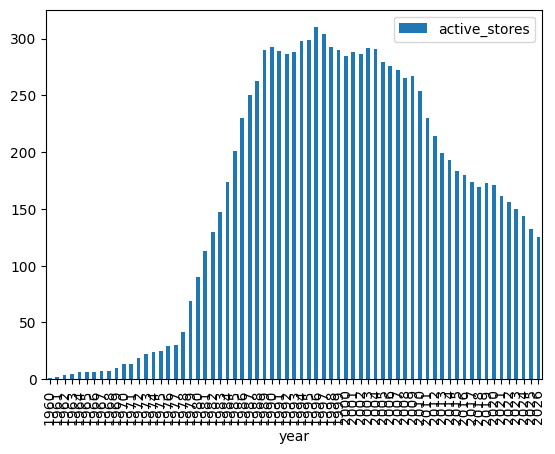

In [30]:
active_by_year.plot(y='active_stores', x='year', kind='bar')

Given changes in filing practices over many decades, I'm zooming in to just after 1990, a decade or so before the first Dollar Store came to Vermont

<Axes: xlabel='year'>

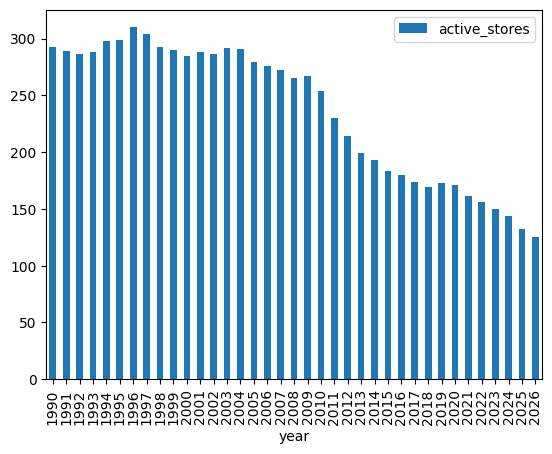

In [31]:
active_by_year_after1990 = active_by_year[active_by_year["year"] >= 1990]

active_by_year_after1990.plot(
    x="year",
    y="active_stores",
    kind="bar"
)


Export the info I need for my three charts to the docs folder

In [32]:
active_by_year.to_csv('docs/stores_active_by_year.csv', index=False)

active_by_year_after1990.to_csv('docs/stores_active_by_year_after1990.csv', index=False)